In [4]:
# 1.Use Keras' ImageDataGenerator to apply at least three types of data augmentation (such as rotation, flip, and zoom) 
# to a set of 20 sample images of food items, and display 5 augmented images for any one input image.<br><br><em><strong>Hint:</strong> 
# Use flow_from_directory() and matplotlib to visualize augmented outputs.</em>

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
print("Total food images:", len(os.listdir("food")))
print(os.listdir("food"))

Total food images: 20
['food01.jpg', 'food02.jpg', 'food03.jpg', 'food04.jpg', 'food05.jpg', 'food06.jpg', 'food07.jpg', 'food08.jpg', 'food09.jpg', 'food10.jpg', 'food11.jpg', 'food12.jpg', 'food13.jpg', 'food14.jpg', 'food15.jpg', 'food16.jpg', 'food17.jpg', 'food18.jpg', 'food19.jpg', 'food20.jpg']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.2
)

In [8]:
generator = datagen.flow_from_directory(
    "food",
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

print("Total images found:", generator.samples)

Found 0 images belonging to 0 classes.
Total images found: 0


In [15]:
from tensorflow.keras.utils import load_img, img_to_array

img_path = "food/food01.jpg"

img = load_img(img_path, target_size=(224, 224))
input_image = img_to_array(img)

print("Image shape:", input_image.shape)

Image shape: (224, 224, 3)


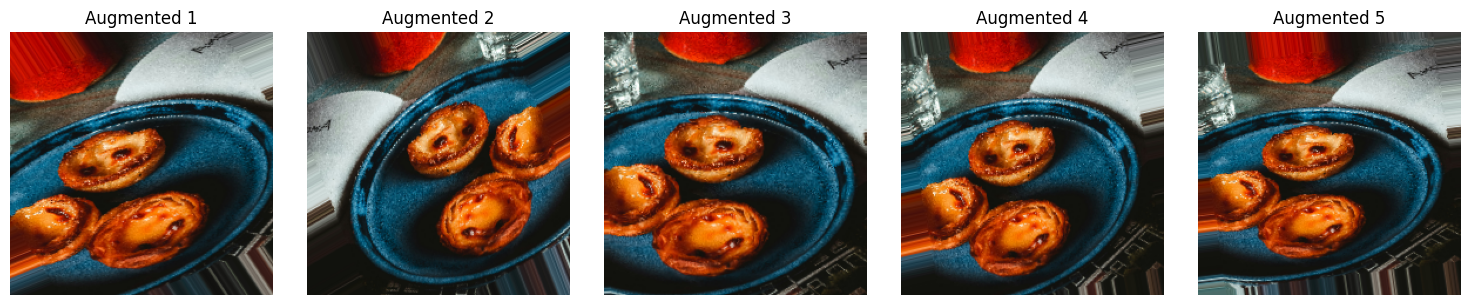

In [17]:
plt.figure(figsize=(15, 3))

for i in range(5):

    image_batch = np.expand_dims(input_image, axis=0)

    augmented_image = next(
        datagen.flow(image_batch, batch_size=1, shuffle=False)
    )[0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image.astype("uint8"))
    plt.axis("off")
    plt.title("Augmented " + str(i + 1))

plt.tight_layout()
plt.show()

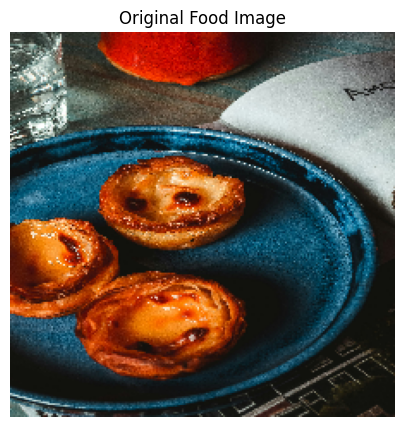

In [18]:
plt.figure(figsize=(5, 5))

plt.imshow(input_image.astype("uint8"))
plt.axis("off")
plt.title("Original Food Image")

plt.show()

In [22]:
from tensorflow.keras.utils import load_img, img_to_array

img_path = "food/food18.jpg"

img = load_img(img_path, target_size=(224, 224))
input_image = img_to_array(img)

print("Image shape:", input_image.shape)

Image shape: (224, 224, 3)


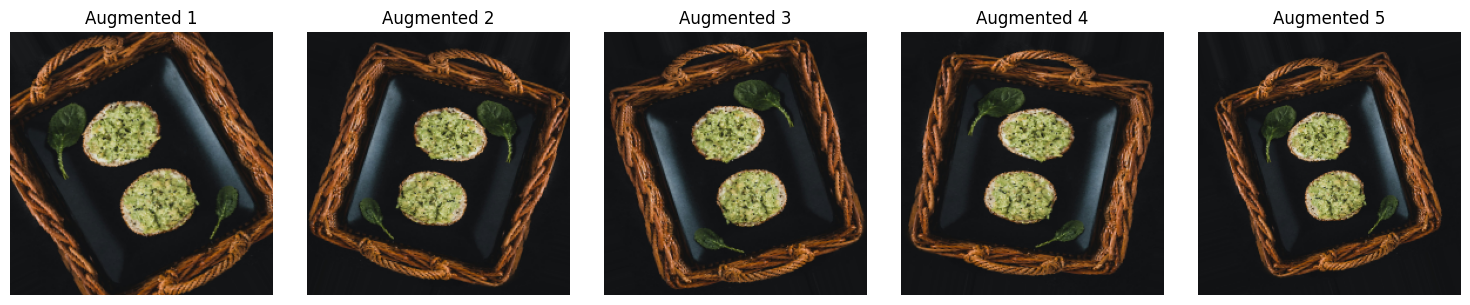

In [23]:
plt.figure(figsize=(15, 3))

for i in range(5):

    image_batch = np.expand_dims(input_image, axis=0)

    augmented_image = next(
        datagen.flow(image_batch, batch_size=1, shuffle=False)
    )[0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image.astype("uint8"))
    plt.axis("off")
    plt.title("Augmented " + str(i + 1))

plt.tight_layout()
plt.show()

In [26]:
# 2.Load the VGG16 model (with imagenet weights, include_top=False) in Keras and use it to extract features from a batch of 30 sneaker images 
# (from a local directory), then save the extracted features as a .npy file.

import pandas as pd

csv_path = "sneaker/fashion-mnist_train.csv"

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (60000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0 

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv("sneaker/fashion-mnist_train.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns[:10].tolist())

Dataset shape: (60000, 785)
Columns: ['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9']


In [30]:
print(df.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [31]:
sneakers = df[df["label"] == 7].head(30)

print("Sneakers found:", len(sneakers))

pixel_columns = [col for col in df.columns if col != "label"]

for i, (_, row) in enumerate(sneakers.iterrows(), start=1):

    image = row[pixel_columns].values.astype("uint8")
    image = image.reshape(28, 28)

    file_path = f"sneaker/sneaker{i:02d}.png"
    plt.imsave(file_path, image, cmap="gray")

print("30 sneaker images saved successfully!")

Sneakers found: 30
30 sneaker images saved successfully!


In [32]:
sneaker_images = [
    file for file in os.listdir("sneaker")
    if file.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total sneaker images:", len(sneaker_images))

Total sneaker images: 30


In [33]:
csv_path = "sneaker/fashion-mnist_train.csv"

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Dataset loaded successfully!")

Dataset shape: (60000, 785)
Dataset loaded successfully!


In [35]:
sneakers = df[df["label"] == 7].head(30)

print("Sneaker images found:", len(sneakers))

pixel_columns = [col for col in df.columns if col != "label"]

for i, (_, row) in enumerate(sneakers.iterrows(), start=1):

    image = row[pixel_columns].values.astype("uint8")
    image = image.reshape(28, 28)

    file_path = f"sneaker/sneaker{i:02d}.png"

    plt.imsave(file_path, image, cmap="gray")

print("30 sneaker images created successfully!")

Sneaker images found: 30
30 sneaker images created successfully!


In [36]:
sneaker_images = [
    file for file in os.listdir("sneaker")
    if file.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total sneaker images:", len(sneaker_images))
print(sneaker_images)

Total sneaker images: 30
['sneaker01.png', 'sneaker02.png', 'sneaker03.png', 'sneaker04.png', 'sneaker05.png', 'sneaker06.png', 'sneaker07.png', 'sneaker08.png', 'sneaker09.png', 'sneaker10.png', 'sneaker11.png', 'sneaker12.png', 'sneaker13.png', 'sneaker14.png', 'sneaker15.png', 'sneaker16.png', 'sneaker17.png', 'sneaker18.png', 'sneaker19.png', 'sneaker20.png', 'sneaker21.png', 'sneaker22.png', 'sneaker23.png', 'sneaker24.png', 'sneaker25.png', 'sneaker26.png', 'sneaker27.png', 'sneaker28.png', 'sneaker29.png', 'sneaker30.png']


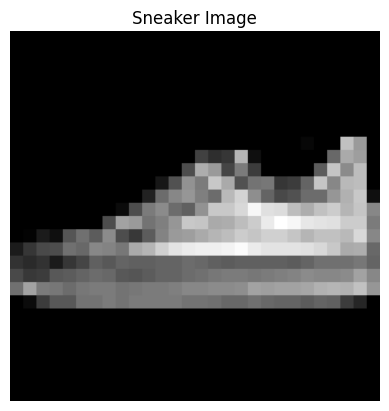

In [37]:
img = load_img(
    "sneaker/sneaker01.png",
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis("off")
plt.title("Sneaker Image")
plt.show()

In [38]:
model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 40s 1us/step
VGG16 loaded successfully!


In [39]:
image_data = []

for file in sneaker_images[:30]:

    img_path = os.path.join("sneaker", file)

    img = load_img(
        img_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)

    image_data.append(img_array)

image_data = np.array(image_data)

print("Image data shape:", image_data.shape)

Image data shape: (30, 224, 224, 3)


In [40]:
image_data = preprocess_input(image_data)

print("Images preprocessed successfully!")

Images preprocessed successfully!


In [41]:
features = model.predict(image_data)

print("Feature extraction completed!")
print("Feature shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Feature extraction completed!
Feature shape: (30, 7, 7, 512)


In [42]:
np.save("vgg16_features.npy", features)

print("Features saved successfully!")
print("File: vgg16_features.npy")

Features saved successfully!
File: vgg16_features.npy


In [43]:
loaded_features = np.load("vgg16_features.npy")

print("Loaded feature shape:", loaded_features.shape)
print("vgg16_features.npy loaded successfully!")

Loaded feature shape: (30, 7, 7, 512)
vgg16_features.npy loaded successfully!


In [44]:
# 3.Fine-tune a ResNet50 model (pre-trained on ImageNet) to classify whether a selfie image contains glasses or not, 
# by unfreezing the last 20 layers and training on a small dataset of at least 40 images.<br><br><em><strong>Constraint:</strong> Only retrain the last 20 layers; keep the rest frozen.</em>

import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [48]:
glasses_count = len(os.listdir(" glasses_dataset/glasses"))
no_glasses_count = len(os.listdir(" glasses_dataset/no_glasses"))

print("Glasses images:", glasses_count)
print("No-glasses images:", no_glasses_count)
print("Total images:", glasses_count + no_glasses_count)

Glasses images: 5
No-glasses images: 5
Total images: 10


In [49]:
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

In [50]:
data_generator = datagen.flow_from_directory(
    " glasses_dataset",
    target_size=(224, 224),
    batch_size=2,
    class_mode="binary",
    shuffle=True
)

print("Class labels:", data_generator.class_indices)

Found 0 images belonging to 3 classes.
Class labels: {'.ipynb_checkpoints': 0, 'glasses': 1, 'no_glasses': 2}


In [51]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 64s 1us/step
ResNet50 loaded successfully!


In [52]:
base_model.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

print("Last 20 layers are trainable.")

Last 20 layers are trainable.


In [53]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(64, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 9,062,529 (34.57 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [54]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [56]:
model.save("resnet50_glasses_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [58]:
# 4.Compare the validation accuracy and overfitting tendency between feature extraction (all layers frozen) and full fine-tuning
# (some layers trainable) using a small set of 2-3 classes of T-shirt images. Write a short paragraph summarizing which approach generalized better and why.

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [59]:
df = pd.read_csv("sneaker/fashion-mnist_train.csv")

print("Dataset shape:", df.shape)

Dataset shape: (60000, 785)


In [60]:
selected_labels = [0, 2, 6]

data = df[df["label"].isin(selected_labels)].groupby("label").head(20)

print("Total images:", len(data))
print(data["label"].value_counts())

Total images: 60
label
2    20
6    20
0    20
Name: count, dtype: int64


In [62]:
X = []
y = []

pixel_columns = [col for col in df.columns if col != "label"]

for _, row in data.iterrows():

    image = row[pixel_columns].values.astype("float32")

    image = image.reshape(28, 28)

    image = tf.image.resize(
        image[..., np.newaxis],
        (224, 224)
    )
    
    image = tf.image.grayscale_to_rgb(image)

    X.append(image.numpy())
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("Image data shape:", X.shape)
print("Labels shape:", y.shape)

Image data shape: (60, 224, 224, 3)
Labels shape: (60,)


In [63]:
label_map = {
    0: 0,   
    2: 1,   
    6: 2    
}

y = np.array([label_map[label] for label in y])

print("Converted labels:", np.unique(y))

Converted labels: [0 1 2]


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))

Training images: 48
Validation images: 12


In [65]:
# Feature extraction

In [66]:
X_train_processed = preprocess_input(X_train)
X_val_processed = preprocess_input(X_val)

In [67]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully!")

VGG16 loaded successfully!


In [68]:
base_model.trainable = False

print("All VGG16 layers are frozen.")

All VGG16 layers are frozen.


In [69]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

output = Dense(3, activation="softmax")(x)

feature_model = Model(
    inputs=base_model.input,
    outputs=output
)

feature_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Feature extraction model ready!")

Feature extraction model ready!


In [70]:
history_feature = feature_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=5,
    batch_size=8,
    verbose=1
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3958 - loss: 1.6001 - val_accuracy: 0.2500 - val_loss: 1.8030
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7917 - loss: 0.3679 - val_accuracy: 0.4167 - val_loss: 1.6692
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9792 - loss: 0.1153 - val_accuracy: 0.3333 - val_loss: 1.8959
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 1.0000 - loss: 0.0493 - val_accuracy: 0.5000 - val_loss: 1.9973
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 1.0000 - loss: 0.0321 - val_accuracy: 0.4167 - val_loss: 1.9064


In [71]:
#fine-turning

In [73]:
fine_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

fine_base.trainable = False

for layer in fine_base.layers[-4:]:
    layer.trainable = True

print("Last 4 VGG16 layers are trainable.")

Last 4 VGG16 layers are trainable.


In [74]:
x = fine_base.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

output = Dense(3, activation="softmax")(x)

fine_model = Model(
    inputs=fine_base.input,
    outputs=output
)

fine_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model ready!")

Fine-tuning model ready!


In [75]:
history_fine = fine_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=5,
    batch_size=8,
    verbose=1
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4167 - loss: 2.6414 - val_accuracy: 0.5000 - val_loss: 0.9523
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7500 - loss: 0.5311 - val_accuracy: 0.5833 - val_loss: 0.9446
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8958 - loss: 0.2981 - val_accuracy: 0.7500 - val_loss: 0.9073
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9792 - loss: 0.1655 - val_accuracy: 0.6667 - val_loss: 0.6258
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 1.0000 - loss: 0.0339 - val_accuracy: 0.5000 - val_loss: 1.3277


In [76]:
# compare validation accuracy

In [77]:
feature_val_accuracy = history_feature.history["val_accuracy"][-1]
fine_val_accuracy = history_fine.history["val_accuracy"][-1]

print("Feature Extraction Validation Accuracy:",
      round(feature_val_accuracy * 100, 2), "%")

print("Fine-Tuning Validation Accuracy:",
      round(fine_val_accuracy * 100, 2), "%")

Feature Extraction Validation Accuracy: 41.67 %
Fine-Tuning Validation Accuracy: 50.0 %


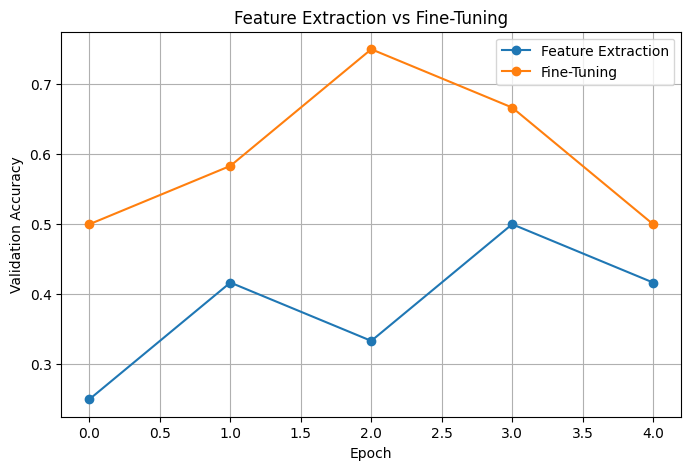

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_feature.history["val_accuracy"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    history_fine.history["val_accuracy"],
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid()

plt.show()

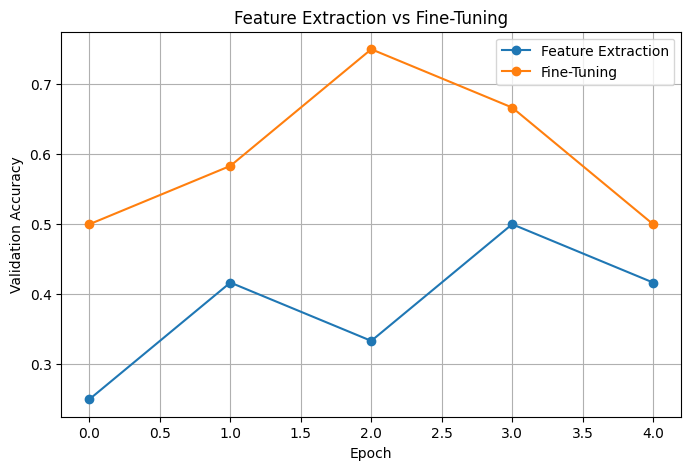

In [79]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_feature.history["val_accuracy"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    history_fine.history["val_accuracy"],
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid()

plt.show()

In [81]:
#5Use ChatGPT or Copilot to generate a Keras code snippet for transfer learning with MobileNetV2 for classifying 3 types of headphones,
# then adapt the code to use your own dataset and run it. Paste both the AI-generated code and your modified version.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


In [82]:
dataset_path = "headphone_dataset"

file_paths = []
labels = []

for file_name in os.listdir(dataset_path):

    file_path = os.path.join(dataset_path, file_name)

    if not os.path.isfile(file_path):
        continue

    name = file_name.lower()

    if "on-ear" in name:
        label = "on_ear"

    elif "over-ear" in name:
        label = "over_ear"

    elif name.startswith("headphone"):
        label = "earbuds"

    else:
        continue

    file_paths.append(file_path)
    labels.append(label)

data = pd.DataFrame({
    "filename": file_paths,
    "label": labels
})

print("Total images:", len(data))
print(data["label"].value_counts())

Total images: 18
label
earbuds     6
on_ear      6
over_ear    6
Name: count, dtype: int64


In [83]:
IMG_SIZE = (224, 224)

class_names = ["earbuds", "on_ear", "over_ear"]

class_to_index = {
    "earbuds": 0,
    "on_ear": 1,
    "over_ear": 2
}

X = []
y = []

for _, row in data.iterrows():

    try:
        image = Image.open(row["filename"]).convert("RGB")
        image = image.resize(IMG_SIZE)

        image_array = np.array(image, dtype=np.float32)

        X.append(image_array)
        y.append(class_to_index[row["label"]])

    except Exception as e:
        print("Error loading:", row["filename"])
        print(e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (18, 224, 224, 3)
y shape: (18,)


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))

Training images: 12
Validation images: 6


In [85]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("MobileNetV2 loaded successfully.")

MobileNetV2 loaded successfully.


In [86]:
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)

In [87]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15
)

In [88]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.4)(x)

output = Dense(
    3,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [89]:
history = model.fit(
    train_datagen.flow(
        X_train,
        y_train,
        batch_size=4,
        shuffle=True
    ),
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4167 - loss: 1.3242 - val_accuracy: 0.5000 - val_loss: 0.9314
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.6667 - loss: 0.8442 - val_accuracy: 0.5000 - val_loss: 0.7200
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8333 - loss: 0.4136 - val_accuracy: 0.6667 - val_loss: 0.5767
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9167 - loss: 0.2915 - val_accuracy: 0.6667 - val_loss: 0.5129
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 1.0000 - loss: 0.1144 - val_accuracy: 0.6667 - val_loss: 0.5380
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9167 - loss: 0.0954 - val_accuracy: 0.6667 - val_loss: 0.5399
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 1.0000 - loss: 0.0321 - val_accuracy: 0.6667 - val_loss: 0.5311
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 1.0000 - loss: 0.0575 - val_accuracy: 0.8333 - val_loss: 0.